In [1]:
"""Onepass (thinking) vs. no-think accuracy comparison across models and benchmarks."""

import json
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# --- configuration ---

FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR = Path("../output")

# max token budget used in all greedy runs
MAX_TOKENS = 32768

# vibrant palette: ColorBrewer Set1 with yellow (#5) replaced by cyan and
# grey (#8) replaced by deep pink, for better on-white visibility
_P = [
    "#E41A1C",  # red
    "#377EB8",  # blue
    "#4DAF4A",  # green
    "#984EA3",  # purple
    "#FF7F00",  # orange
    "#00BCD4",  # cyan  (replaces Set1 yellow)
    "#A65628",  # brown
    "#F781BF",  # pink
    "#FF4081",  # deep pink  (replaces Set1 grey)
]

# colour groups by model family:
#   qwen3 models → blue / teal / cyan (similar, distinct)
#   ocr / or     → pink / purple
#   olmo / llama → orange / brown
# colours match the SERIES dict in notebook 02
SERIES: dict[str, dict] = {
    "qwen3_8b": {"label": "Qwen3-8B", "model_key": "qwen3-8b", "colour": "#377EB8"},
    "qwen3_14b": {"label": "Qwen3-14B", "model_key": "qwen3-14b", "colour": "#009688"},
    "qwen3_32b": {"label": "Qwen3-32B", "model_key": "qwen3-32b", "colour": "#00BCD4"},
    "olmo_3_7b": {"label": "OLMo3-7B", "model_key": "olmo-3-7b", "colour": "#FF7F00"},
    "llama_r1_8b": {
        "label": "Llama-R1-8B",
        "model_key": "llama-r1-8b",
        "colour": "#A65628",
    },
    "ocr_7b": {"label": "OCR-7B", "model_key": "ocr-7b", "colour": "#F781BF"},
    "or_7b": {"label": "OR-7B", "model_key": "or-7b", "colour": "#984EA3"},
}

# benchmarks to plot: display name → key prefix used in the output JSON filenames.
# the full key is built as f"{prefix}_mx{MAX_TOKENS}_onepass" or f"{prefix}_mx{MAX_TOKENS}_nothink"
DATASETS: dict[str, str] = {
    "EvalPlus": "code/evalplus_greedy",
    "BigCodeBench": "code/bigcodebench_greedy",
    "LiveCodeBench": "code/livecodebench_greedy",
    "CodeContests": "code/code_contests_greedy",
    "CRUX-Input": "crux/cruxeval_i_greedy",
    "CRUX-Output": "crux/cruxeval_o_greedy",
}

# font size constants — match notebooks 02 and 03
TITLE_SIZE = 13
FONT_SIZE = 11
TICK_SIZE = 10

In [3]:
def load_accuracy_data() -> dict[str, dict[str, dict]]:
    """Load onepass and nothink pass@1 accuracy for every model and dataset.

    Reads {model_key}_onepass.json and {model_key}_nothink.json from OUTPUT_DIR.
    Missing files or keys are skipped with a warning. 95% CI bounds are included
    where available (pass_at_1_ci field).

    Returns a nested dict: series_key → dataset_label → {
        "onepass": float | None, "onepass_ci": [float, float] | None,
        "nothink": float | None, "nothink_ci": [float, float] | None,
    }
    """
    results: dict[str, dict[str, dict]] = {}

    for series_key, series_info in SERIES.items():
        model_key = series_info["model_key"]
        results[series_key] = {}

        onepass_path = OUTPUT_DIR / f"{model_key}_onepass.json"
        nothink_path = OUTPUT_DIR / f"{model_key}_nothink.json"

        onepass_data = json.load(open(onepass_path)) if onepass_path.exists() else {}
        nothink_data = json.load(open(nothink_path)) if nothink_path.exists() else {}

        for ds_label, prefix in DATASETS.items():
            onepass_key = f"{prefix}_mx{MAX_TOKENS}_onepass"
            nothink_key = f"{prefix}_mx{MAX_TOKENS}_nothink"

            onepass_entry = onepass_data.get(onepass_key)
            nothink_entry = nothink_data.get(nothink_key)

            if onepass_entry is None:
                print(f"  [skip] {series_key} / {onepass_key} not found")
            if nothink_entry is None:
                print(f"  [skip] {series_key} / {nothink_key} not found")

            results[series_key][ds_label] = {
                "onepass": onepass_entry["pass_at_1"] if onepass_entry else None,
                "onepass_ci": onepass_entry.get("pass_at_1_ci")
                if onepass_entry
                else None,
                "nothink": nothink_entry["pass_at_1"] if nothink_entry else None,
                "nothink_ci": nothink_entry.get("pass_at_1_ci")
                if nothink_entry
                else None,
            }

            if onepass_entry and nothink_entry:
                print(
                    f"  {series_key} / {ds_label}: "
                    f"onepass={100 * onepass_entry['pass_at_1']:.1f}%, "
                    f"nothink={100 * nothink_entry['pass_at_1']:.1f}%"
                )

    return results


all_data = load_accuracy_data()

  qwen3_8b / EvalPlus: onepass=42.6%, nothink=63.5%
  qwen3_8b / BigCodeBench: onepass=37.9%, nothink=42.0%
  qwen3_8b / LiveCodeBench: onepass=36.0%, nothink=27.5%
  qwen3_8b / CodeContests: onepass=27.3%, nothink=18.2%
  qwen3_8b / CRUX-Input: onepass=85.8%, nothink=57.9%
  qwen3_8b / CRUX-Output: onepass=88.5%, nothink=52.4%
  qwen3_14b / EvalPlus: onepass=51.7%, nothink=65.1%
  qwen3_14b / BigCodeBench: onepass=46.3%, nothink=43.2%
  qwen3_14b / LiveCodeBench: onepass=47.7%, nothink=28.4%
  qwen3_14b / CodeContests: onepass=46.1%, nothink=14.5%
  qwen3_14b / CRUX-Input: onepass=93.1%, nothink=59.6%
  qwen3_14b / CRUX-Output: onepass=94.6%, nothink=56.5%
  qwen3_32b / EvalPlus: onepass=55.4%, nothink=64.8%
  qwen3_32b / BigCodeBench: onepass=49.0%, nothink=44.2%
  qwen3_32b / LiveCodeBench: onepass=53.2%, nothink=28.7%
  qwen3_32b / CodeContests: onepass=49.7%, nothink=19.4%
  qwen3_32b / CRUX-Input: onepass=93.5%, nothink=61.5%
  qwen3_32b / CRUX-Output: onepass=95.1%, nothink=58.6

In [4]:
# hatch pattern applied to nothink bars to distinguish them visually from thinking bars
_NOTHINK_HATCH = "////"

# alpha for nothink bars — lower than thinking bars so the hatch is clearly readable
_NOTHINK_ALPHA = 0.55


def _add_ci_errorbar(
    ax: plt.Axes,
    x: float,
    y: float,
    ci: list[float] | None,
    colour: str,
) -> None:
    """Draw a 95% CI error bar centred on the top of a bar.

    Asymmetric bounds [lo, hi] are preserved. Does nothing when ci is None.
    """
    if ci is None:
        return
    lo, hi = ci
    # convert proportions to percentages and clip to zero to avoid negative lengths
    yerr_lo = max(0.0, y - lo) * 100
    yerr_hi = max(0.0, hi - y) * 100
    ax.errorbar(
        x,
        y * 100,
        yerr=[[yerr_lo], [yerr_hi]],
        fmt="none",
        color="black",
        capsize=3,
        linewidth=1.2,
        zorder=5,
    )


def plot_accuracy_bars(
    data: dict[str, dict[str, dict]],
    save_path: Path,
    n_cols: int = 2,
) -> None:
    """Plot grouped bar charts comparing onepass vs. no-think accuracy per benchmark.

    One subplot per benchmark, arranged in a 2-column grid matching notebook 02.
    Each subplot contains one bar group per model; within each group the solid bar
    shows onepass (thinking) accuracy and the hatched bar shows nothink accuracy.
    Error bars indicate the 95% confidence interval where available. A shared legend
    is placed below all subplots. Figure width is fixed at 13 inches (3.5 per row).
    Saves the figure as a PNG at save_path.
    """
    series_keys = list(SERIES.keys())
    dataset_labels = list(DATASETS.keys())

    n_rows = (len(dataset_labels) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(13, 3.5 * n_rows),
        squeeze=False,
    )
    flat_axes = axes.flatten()

    # bar geometry: two bars per model group, centred around each integer x position
    n_models = len(series_keys)
    bar_width = 0.35
    group_positions = np.arange(n_models)

    for ax_idx, (ax, ds_label) in enumerate(zip(flat_axes, dataset_labels)):
        for model_idx, series_key in enumerate(series_keys):
            ds_data = data.get(series_key, {}).get(ds_label, {})
            colour = SERIES[series_key]["colour"]

            onepass_val = ds_data.get("onepass")
            nothink_val = ds_data.get("nothink")

            # onepass bar sits to the left of the group centre
            x_onepass = group_positions[model_idx] - bar_width / 2
            # nothink bar sits to the right
            x_nothink = group_positions[model_idx] + bar_width / 2

            # solid fill for thinking (onepass) bars
            if onepass_val is not None:
                ax.bar(
                    x_onepass,
                    onepass_val * 100,
                    width=bar_width,
                    color=colour,
                    alpha=0.85,
                    zorder=3,
                )
                _add_ci_errorbar(
                    ax,
                    x_onepass,
                    onepass_val,
                    ds_data.get("onepass_ci"),
                    colour,
                )

            # hatched fill for no-thinking (nothink) bars
            if nothink_val is not None:
                ax.bar(
                    x_nothink,
                    nothink_val * 100,
                    width=bar_width,
                    color=colour,
                    alpha=_NOTHINK_ALPHA,
                    hatch=_NOTHINK_HATCH,
                    edgecolor="#555555",  # dark grey hatch lines
                    zorder=3,
                )
                _add_ci_errorbar(
                    ax,
                    x_nothink,
                    nothink_val,
                    ds_data.get("nothink_ci"),
                    colour,
                )

        ax.set_title(ds_label, fontsize=TITLE_SIZE, fontweight="bold")
        ax.set_xticks(group_positions)
        ax.set_xticklabels(
            [SERIES[sk]["label"] for sk in series_keys],
            rotation=20,
            ha="right",
            fontsize=TICK_SIZE,
        )
        ax.set_ylabel("pass@1 (%)", fontstyle="italic", fontsize=FONT_SIZE)
        ax.tick_params(axis="y", labelsize=TICK_SIZE)
        ax.set_ylim(bottom=0)
        ax.grid(axis="y", alpha=0.5, linewidth=1.2)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # hide spare axes when the dataset count is not divisible by n_cols
    for ax in flat_axes[len(dataset_labels) :]:
        ax.set_visible(False)

    # shared legend: two entries show what solid vs. hatched bars represent
    _grey = "#555555"
    legend_handles = [
        mpatches.Patch(
            color=_grey,
            alpha=0.85,
            label="Reasoning enabled (default)",
        ),
        mpatches.Patch(
            facecolor="#DDDDDD",  # light grey background
            edgecolor="#555555",  # dark grey hatch lines
            hatch=_NOTHINK_HATCH,
            label="Reasoning disabled",
        ),
    ]
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=2,
        fontsize=FONT_SIZE,
        frameon=False,
        bbox_to_anchor=(0.5, 0.0),
    )

    fig.tight_layout(rect=[0, 0.04, 1, 1], h_pad=2.5, w_pad=2)
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"saved → {save_path}")
    plt.show()

saved → ../figures/03_accuracy.png


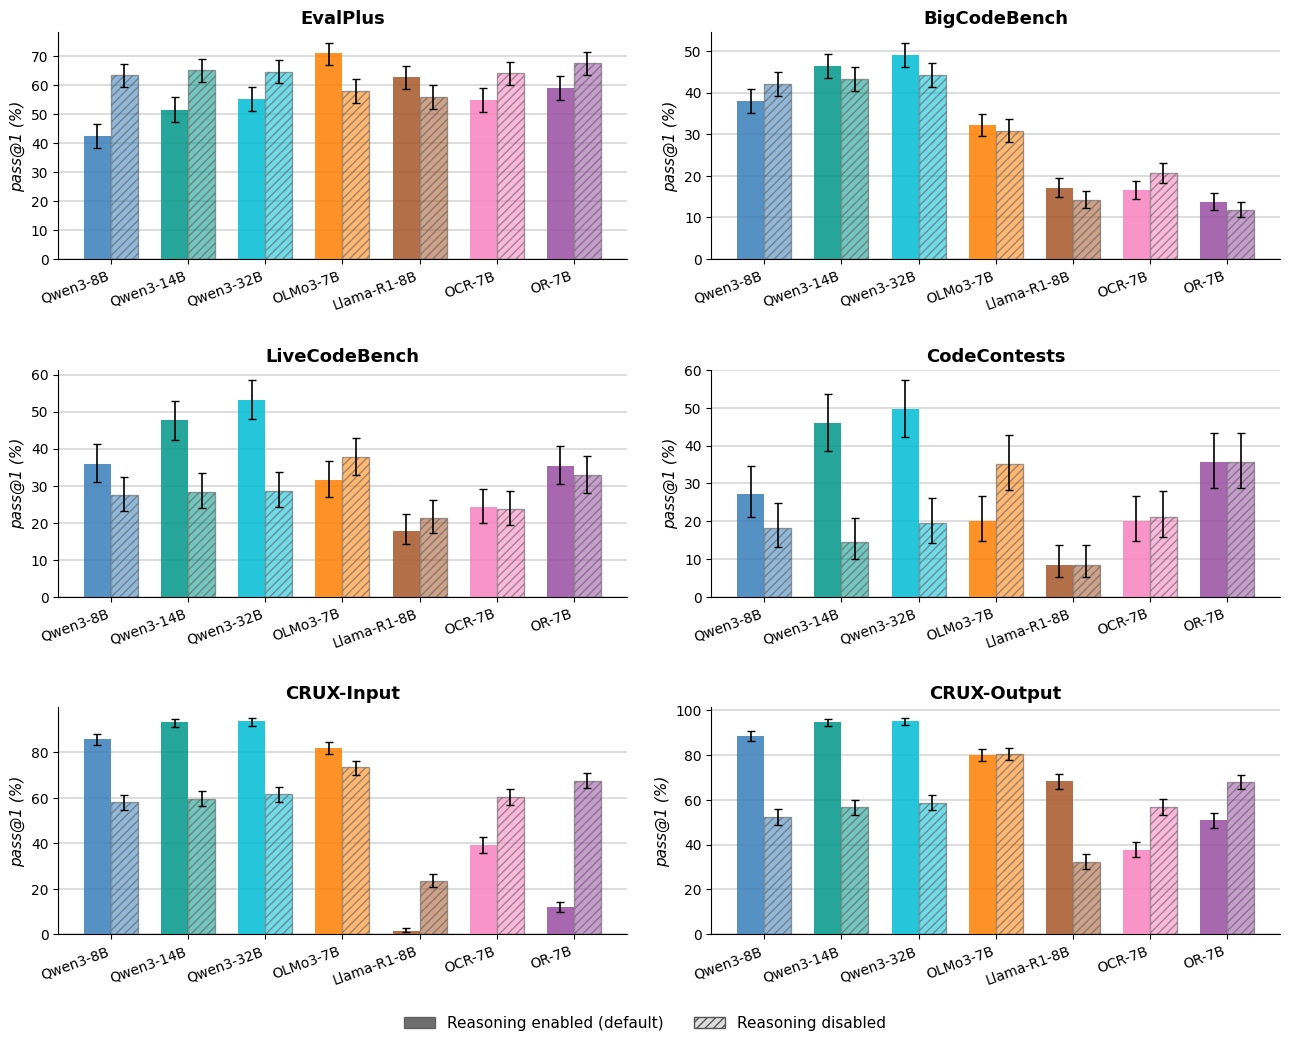

In [5]:
# --- onepass vs. nothink accuracy bar chart ---
# solid bars = thinking (onepass), hatched bars = no thinking (nothink)
# error bars show 95% confidence intervals

plot_accuracy_bars(
    data=all_data,
    save_path=FIGURES_DIR / "03_accuracy.png",
)